In [62]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [63]:
df = pd.read_csv('Salary_Data.csv')

df.info()
df[['YearsExperience', 'Salary']].describe()
df.head()

df[['YearsExperience', 'Salary']].isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


YearsExperience    0
Salary             0
dtype: int64

In [64]:
X = df[['YearsExperience']]
y = df['Salary']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)
print("Training Set Size :", len(X_train))
print("Testing Set Size :", len(X_test))

Training Set Size : 24
Testing Set Size : 6


In [66]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.532e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [67]:
print("Slope (Coefficinet) :", model.coef_[0])
print("Intercept :", model.intercept_)

Slope (Coefficinet) : 9423.815323030976
Intercept : 25321.583011776813


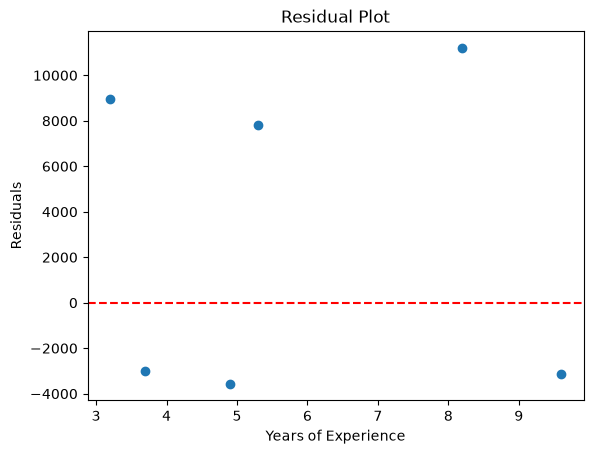

,Actual,Predicted,Error
27,112635.0,115790.210113,3155.210113
15,67938.0,71498.278095,3560.278095
23,113812.0,102596.868661,11215.131339
17,83088.0,75267.804224,7820.195776
8,64445.0,55477.792045,8967.207955
9,57189.0,60189.699707,3000.699707


In [68]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred,
    "Error" : abs(y_test - y_pred)
})

residuals = y_test - y_pred
plt.scatter(X_test["YearsExperience"], residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Years of Experience")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

results

In [69]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE) :", mae)
print("Mean Squared Error (MSE) :", mse)
print("Root Mean Squared Error (RMSE) :", rmse)
print("R-squared (R2) :", r2)

Mean Absolute Error (MAE) : 6286.453830757749
Mean Squared Error (MSE) : 49830096.85590839
Root Mean Squared Error (RMSE) : 7059.04362190151
R-squared (R2) : 0.9024461774180497


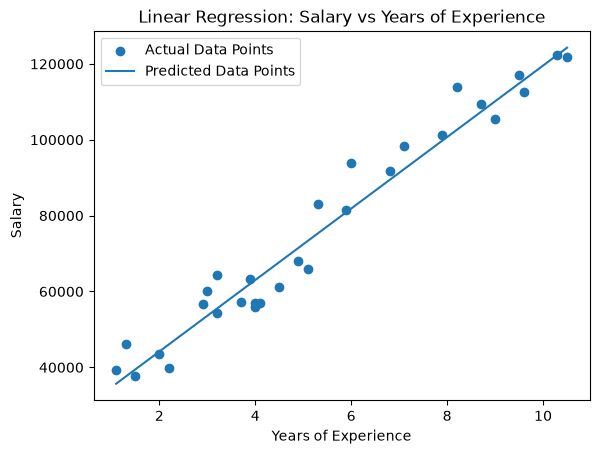

In [70]:
plt.scatter(X,y, label = "Actual Data Points")

plt.plot(X, model.predict(X), label = "Predicted Data Points")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression: Salary vs Years of Experience")
plt.legend()
plt.show()

In [71]:
new_data = pd.DataFrame({
    "YearsExperience": [2.4]
})

print(model.predict(new_data))

[47938.73978705]
